# Headwind alignment options: April adj-h vs June (two variants)

Visualize two candidate June 2026 configurations that align with April's adj-h forecast at Dec-15:

- **Option A — Canonical June + 160k headwind addback.** Keep `holiday_threshold = -0.032` (cap426 baseline) and reduce the headwind anchor magnitude by 160k. New anchor: −1,338k desktop.
- **Option B — Thresh-matched June + 260k headwind addback.** Switch June to `holiday_threshold = -0.05` (matching April's package-default-at-the-time) and reduce headwind anchor by 260k. New anchor: −1,238k desktop.

Comparison baseline: April's currently-shipped `adj-h` (anchor = −1,498k).

All series are no-Iran desktop world DAU (sum of 45 tiles → country=ALL, segment={"os":"ALL"}). 28-day MA computed on the stitched training+forecast series so windows are always full.


In [1]:
# setup
import sys
from pathlib import Path
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
sys.path.insert(0, "src")
from mozaic_daily.adjustments import render_adjustment, apply_net_adjustment_to_series

# Three desktop world-DAU model curves (no-Iran, country=ALL os=ALL)
APRIL_PARQUET = Path("data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet")
JUNE_CANONICAL_PARQUET = Path("data-official/2026-06/desktop_cps0.15983_thresh032_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-17.ld-D.raw.parquet")
JUNE_THRESHMATCH_PARQUET = Path("param_scan_results/cps0.15983_thresh050_recent13_cpr0.7_ncp25_clip0.6/mozaic_daily_forecast.2026-05-17.ld-D.raw.parquet")

APRIL_FCST_START = pd.Timestamp("2026-04-01")
JUNE_FCST_START = pd.Timestamp("2026-05-17")

# Headwind config: April uses the on-disk values; Options A and B use the same start/anchor but reduced magnitude
HEADWIND_BASE = {"type": "linear_ramp", "start_date": "2026-04-01", "anchor_date": "2026-12-15"}
APRIL_ANCHOR_DAU   = -1497870   # current shipped value
OPTION_A_ANCHOR_DAU = -1497870 + 160000  # canonical June + 160k addback
OPTION_B_ANCHOR_DAU = -1497870 + 260000  # thresh-match June + 260k addback

print(f"April adj-h headwind anchor:  {APRIL_ANCHOR_DAU:>10,d}")
print(f"Option A (canonical June):    {OPTION_A_ANCHOR_DAU:>10,d}   (April + 160k)")
print(f"Option B (thresh-match June): {OPTION_B_ANCHOR_DAU:>10,d}   (April + 260k)")


def load_world_curve(path):
    """Return continuous training+forecast series for country=ALL, os=ALL desktop DAU."""
    df = pd.read_parquet(path)
    world = df[(df.country == "ALL") & (df.segment == '{"os": "ALL"}')].copy()
    world["target_date"] = pd.to_datetime(world["target_date"])
    return world[["target_date", "data_type", "dau"]].sort_values("target_date").reset_index(drop=True)


april_curve    = load_world_curve(APRIL_PARQUET)
june_canon     = load_world_curve(JUNE_CANONICAL_PARQUET)
june_threshmat = load_world_curve(JUNE_THRESHMATCH_PARQUET)

for name, df in [("april", april_curve), ("june_canonical", june_canon), ("june_threshmatch", june_threshmat)]:
    print(f"{name:<20}: {len(df)} rows  ({df.target_date.min().date()} -> {df.target_date.max().date()})")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


April adj-h headwind anchor:  -1,497,870
Option A (canonical June):    -1,337,870   (April + 160k)
Option B (thresh-match June): -1,237,870   (April + 260k)
april               : 2922 rows  (2020-01-01 -> 2027-12-31)
june_canonical      : 2922 rows  (2020-01-01 -> 2027-12-31)
june_threshmatch    : 2922 rows  (2020-01-01 -> 2027-12-31)


In [2]:
# apply-headwinds
def apply_headwind_to_curve(curve, anchor_dau, forecast_start):
    """Apply linear-ramp headwind to a stitched training+forecast curve.
    Returns a DataFrame with [target_date, dau_raw, dau_adjh, headwind_value]."""
    spec = {**HEADWIND_BASE, "desktop_dau": anchor_dau, "mobile_dau": 0}
    net = render_adjustment(spec, curve["target_date"].values)
    # apply_net_adjustment_to_series masks to forecast_start onward
    raw_series = pd.Series(curve["dau"].values, index=pd.DatetimeIndex(curve["target_date"]))
    adj_series = apply_net_adjustment_to_series(raw_series, net, "desktop", forecast_start)
    out = curve.copy().rename(columns={"dau": "dau_raw"})
    out["dau_adjh"] = adj_series.values
    out["headwind_value"] = (out["dau_adjh"] - out["dau_raw"]).round(1)
    return out


april_adjh    = apply_headwind_to_curve(april_curve,    APRIL_ANCHOR_DAU,    APRIL_FCST_START)
june_option_a = apply_headwind_to_curve(june_canon,     OPTION_A_ANCHOR_DAU, JUNE_FCST_START)
june_option_b = apply_headwind_to_curve(june_threshmat, OPTION_B_ANCHOR_DAU, JUNE_FCST_START)

# 28dMA on full series so window is always seeded
for df in (april_adjh, june_option_a, june_option_b):
    df["dau_adjh_ma28"] = df["dau_adjh"].rolling(28, min_periods=28).mean()
    df["dau_raw_ma28"]  = df["dau_raw"].rolling(28, min_periods=28).mean()

# Sanity check: headwind value at Dec-15 should equal anchor magnitude (linear ramp reaches 100% at anchor date)
for name, df, expected in [("April",      april_adjh,    APRIL_ANCHOR_DAU),
                            ("Option A",   june_option_a, OPTION_A_ANCHOR_DAU),
                            ("Option B",   june_option_b, OPTION_B_ANCHOR_DAU)]:
    val = df.loc[df.target_date == pd.Timestamp("2026-12-15"), "headwind_value"].iloc[0]
    print(f"{name:<10}: headwind at Dec-15 = {val:>10,.0f}  (expected {expected:>10,d})")


April     : headwind at Dec-15 = -1,497,870  (expected -1,497,870)
Option A  : headwind at Dec-15 = -1,337,870  (expected -1,337,870)
Option B  : headwind at Dec-15 = -1,237,870  (expected -1,237,870)


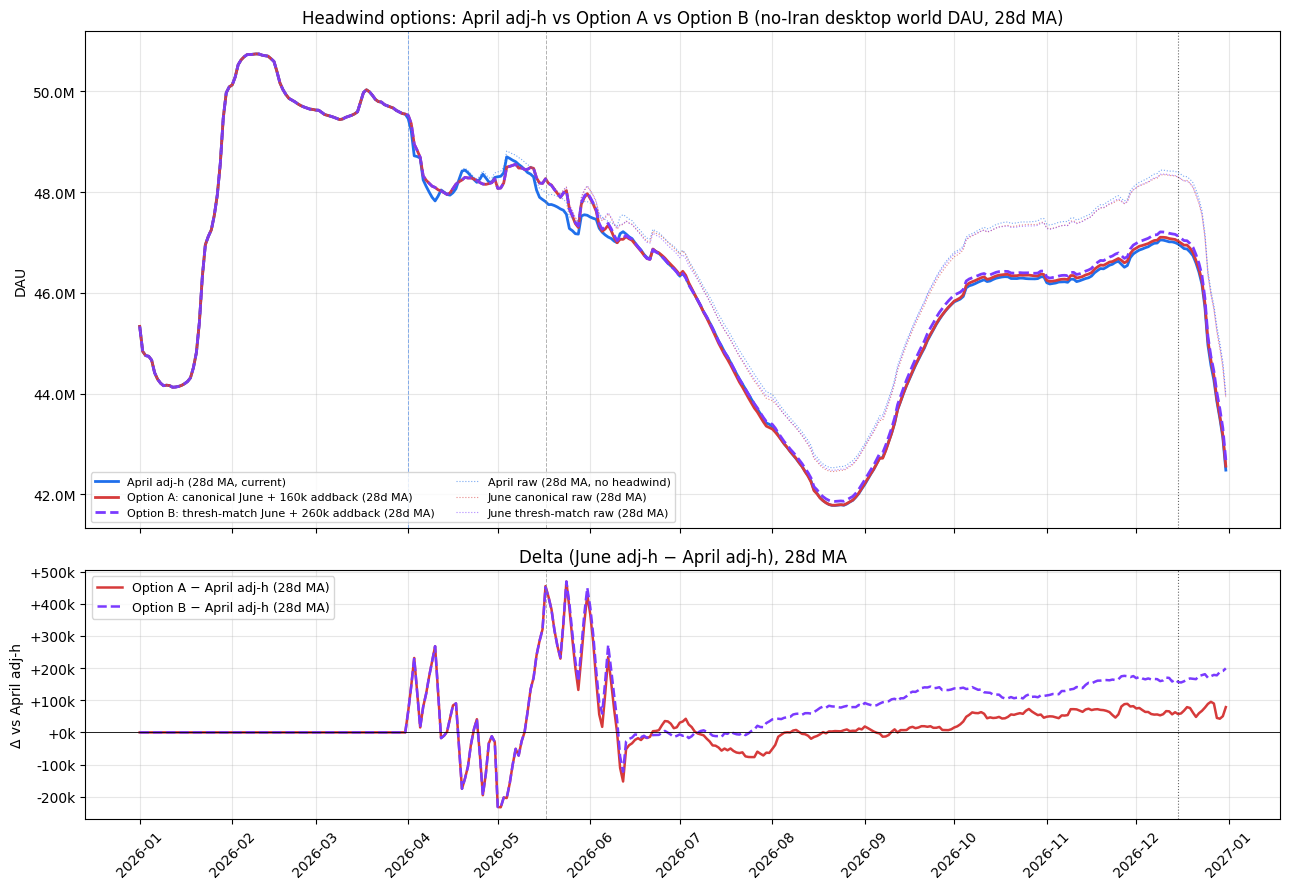

In [3]:
# plot-options
fig, axes = plt.subplots(2, 1, figsize=(13, 9), gridspec_kw={"height_ratios": [3, 1.5]}, sharex=True)

PLOT_START = pd.Timestamp("2026-01-01")
PLOT_END   = pd.Timestamp("2026-12-31")

APRIL_COLOR = "#1f6feb"
OPTION_A_COLOR = "#d63a3a"   # red
OPTION_B_COLOR = "#7a3aff"   # purple

def slice_(df, s, e):
    return df[(df.target_date >= s) & (df.target_date <= e)].copy()

a = slice_(april_adjh,    PLOT_START, PLOT_END)
oa = slice_(june_option_a, PLOT_START, PLOT_END)
ob = slice_(june_option_b, PLOT_START, PLOT_END)

# Top: 28dMA adj-h overlay for all three
ax = axes[0]
ax.plot(a["target_date"],  a["dau_adjh_ma28"],
        color=APRIL_COLOR, lw=2.0, label="April adj-h (28d MA, current)")
ax.plot(oa["target_date"], oa["dau_adjh_ma28"],
        color=OPTION_A_COLOR, lw=2.0, label="Option A: canonical June + 160k addback (28d MA)")
ax.plot(ob["target_date"], ob["dau_adjh_ma28"],
        color=OPTION_B_COLOR, lw=2.0, ls="--", label="Option B: thresh-match June + 260k addback (28d MA)")

# Show actuals (June training rows) and raw forecasts as thin reference lines
ax.plot(a["target_date"],  a["dau_raw_ma28"],
        color=APRIL_COLOR, lw=0.8, ls=":", alpha=0.6, label="April raw (28d MA, no headwind)")
ax.plot(oa["target_date"], oa["dau_raw_ma28"],
        color=OPTION_A_COLOR, lw=0.8, ls=":", alpha=0.6, label="June canonical raw (28d MA)")
ax.plot(ob["target_date"], ob["dau_raw_ma28"],
        color=OPTION_B_COLOR, lw=0.8, ls=":", alpha=0.6, label="June thresh-match raw (28d MA)")

ax.axvline(APRIL_FCST_START, color=APRIL_COLOR, ls="--", lw=0.7, alpha=0.5)
ax.axvline(JUNE_FCST_START,  color="grey",      ls="--", lw=0.7, alpha=0.6)
ax.axvline(pd.Timestamp("2026-12-15"), color="black", ls=":", lw=0.8, alpha=0.6)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_title("Headwind options: April adj-h vs Option A vs Option B (no-Iran desktop world DAU, 28d MA)")
ax.set_ylabel("DAU")
ax.legend(loc="lower left", fontsize=8, ncol=2)

# Bottom: delta vs April adj-h
ax = axes[1]
def merge_delta(df_opt, label):
    m = df_opt[["target_date", "dau_adjh_ma28"]].merge(
        a[["target_date", "dau_adjh_ma28"]].rename(columns={"dau_adjh_ma28": "april_ma28"}),
        on="target_date", how="left",
    )
    m["delta"] = m["dau_adjh_ma28"] - m["april_ma28"]
    return m

m_a = merge_delta(oa, "Option A")
m_b = merge_delta(ob, "Option B")
ax.plot(m_a["target_date"], m_a["delta"], color=OPTION_A_COLOR, lw=1.8, label="Option A − April adj-h (28d MA)")
ax.plot(m_b["target_date"], m_b["delta"], color=OPTION_B_COLOR, lw=1.8, ls="--", label="Option B − April adj-h (28d MA)")
ax.axhline(0, color="black", lw=0.6)
ax.axvline(JUNE_FCST_START, color="grey", ls="--", lw=0.7, alpha=0.6)
ax.axvline(pd.Timestamp("2026-12-15"), color="black", ls=":", lw=0.8, alpha=0.6)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:+.0f}k"))
ax.set_ylabel("Δ vs April adj-h")
ax.set_title("Delta (June adj-h − April adj-h), 28d MA")
ax.legend(loc="best", fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [4]:
# numerical-table
probe_dates = [pd.Timestamp(d) for d in [
    "2026-05-17",  # June fcst start
    "2026-07-01",
    "2026-10-01",
    "2026-12-15",  # anchor date
]]

def lookup(df, col, d):
    s = df.loc[df.target_date == d, col]
    return float(s.iloc[0]) if len(s) and not np.isnan(s.iloc[0]) else np.nan

rows = []
for d in probe_dates:
    rows.append({
        "date": d.date(),
        "April adj-h MA28":    lookup(april_adjh,    "dau_adjh_ma28", d),
        "Option A MA28":       lookup(june_option_a, "dau_adjh_ma28", d),
        "Option B MA28":       lookup(june_option_b, "dau_adjh_ma28", d),
        "Option A − April":    lookup(june_option_a, "dau_adjh_ma28", d) - lookup(april_adjh, "dau_adjh_ma28", d),
        "Option B − April":    lookup(june_option_b, "dau_adjh_ma28", d) - lookup(april_adjh, "dau_adjh_ma28", d),
    })
tbl = pd.DataFrame(rows)
for c in ("April adj-h MA28", "Option A MA28", "Option B MA28"):
    tbl[c] = tbl[c].map(lambda v: f"{v/1e6:.3f}M" if pd.notna(v) else "—")
for c in ("Option A − April", "Option B − April"):
    tbl[c] = tbl[c].map(lambda v: f"{v/1e3:+.1f}k" if pd.notna(v) else "—")
print(tbl.to_string(index=False))


      date April adj-h MA28 Option A MA28 Option B MA28 Option A − April Option B − April
2026-05-17          47.811M       48.265M       48.262M          +454.7k          +451.2k
2026-07-01          46.330M       46.361M       46.324M           +30.4k            -6.3k
2026-10-01          45.821M       45.837M       45.958M           +15.4k          +136.8k
2026-12-15          46.970M       47.026M       47.126M           +57.0k          +156.7k
